In [1]:
from pathlib import Path
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Configuração de fonte para suporte a caracteres acentuados nos gráficos.
# Sem isso, o matplotlib pode renderizar acentos como "?" dependendo do
# backend e da fonte padrão do sistema.
matplotlib.rcParams["font.family"] = "sans-serif"
matplotlib.rcParams["font.sans-serif"] = ["DejaVu Sans", "Arial", "Helvetica", "sans-serif"]
matplotlib.rcParams["axes.unicode_minus"] = False

%matplotlib inline

DOCS_DIR = Path("../docs")
DOCS_DIR.mkdir(exist_ok=True)

In [2]:
df = pd.read_csv("../dados/respostas_limpo.csv")

In [3]:
# Variáveis selecionadas para o clustering
#
# Foco em duas dimensões principais:
#   1. Perfil do gerador: tamanho e tipo da unidade
#      (tipo_gerador, quantidade_gerada, num_pessoas)
#   2. Comportamento e potencial de mudança em relação aos resíduos
#      (destino_atual, interesse_aprender, tentativa_reutilizacao)
#
# Variáveis como tipo_atividade, bairro_cidade, tipos_residuo,
# residuos_organicos, origem_residuo, caracteristica_residuo,
# custo_destinacao e potencial_reaproveitamento foram mantidas de fora
# nesta versão para manter o modelo simples e explicável no MVP.
# Elas podem ser incorporadas em versões futuras para refinar os perfis.

colunas = [
    "tipo_gerador",
    "quantidade_gerada",
    "num_pessoas",
    "destino_atual",
    "interesse_aprender",
    "tentativa_reutilizacao",
]

In [4]:
# 9 respostas sem num_pessoas e interesse_aprender foram removidas
# do clustering (formulário atualizado após as primeiras coletas).
df_cluster = df[colunas].copy().dropna(subset=["num_pessoas", "interesse_aprender"])
print(f"{len(df_cluster)}/{len(df)} respostas utilizadas no clustering")
df_cluster.head()

152/161 respostas utilizadas no clustering


,tipo_gerador,quantidade_gerada,num_pessoas,destino_atual,interesse_aprender,tentativa_reutilizacao
9,Pessoa física (residência),5–10 kg por semana,1 a 3,Coleta seletiva,Sim,Sim
10,Pessoa física (residência),1–5 kg por semana,1 a 3,Coleta seletiva,Sim,Sim
11,Pessoa física (residência),1–5 kg por semana,1 a 3,Coleta seletiva,Sim,Não
12,Pessoa física (residência),1–5 kg por semana,1 a 3,Coleta pública comum,Talvez,Não
13,Pessoa física (residência),5–10 kg por semana,1 a 3,Coleta pública comum,Talvez,Não


In [5]:
# One-hot encoding das colunas categóricas
X = pd.get_dummies(df_cluster, drop_first=False)

X.head()
X.shape

(152, 29)

In [6]:
k = 3 
seed = 2016

kmeans = KMeans(n_clusters=k, random_state=seed, n_init='auto')

df_cluster["cluster"] = kmeans.fit_predict(X)
df_cluster["cluster"].value_counts().sort_index()


cluster
0    55
1    52
2    45
Name: count, dtype: int64

In [7]:
# Análise dos perfis de cada cluster antes de atribuir rótulos.
# Rodar esta célula e analisar a moda de cada variável por cluster
# para decidir manualmente os nomes dos perfis.

df_cluster.groupby("cluster")[colunas].agg(lambda x: x.mode().iloc[0])

,tipo_gerador,quantidade_gerada,num_pessoas,destino_atual,interesse_aprender,tentativa_reutilizacao
cluster,,,,,,
0,Pessoa física (residência),1–5 kg por semana,1 a 3,Coleta pública comum,Talvez,Não
1,Pessoa física (residência),1–5 kg por semana,1 a 3,Coleta pública comum,Sim,Sim
2,Pessoa física (residência),1–5 kg por semana,1 a 3,Coleta pública comum,Sim,Não


In [8]:
rotulos = {0: "Indecisos", 1: "Engajados", 2: "Potencial latente"}
df_cluster["perfil"] = df_cluster["cluster"].map(rotulos)
df_cluster["perfil"].value_counts()

perfil
Indecisos            55
Engajados            52
Potencial latente    45
Name: count, dtype: int64

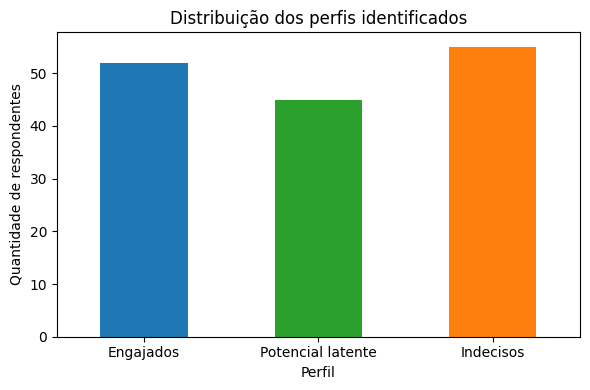

In [9]:
cores_perfil = {"Engajados": "tab:blue", "Indecisos": "tab:orange", "Potencial latente": "tab:green"}
contagens = df_cluster["perfil"].value_counts().reindex(["Engajados", "Potencial latente", "Indecisos"])

plt.figure(figsize=(6, 4))
contagens.plot(kind="bar", color=[cores_perfil[p] for p in contagens.index])
plt.title("Distribuição dos perfis identificados")
plt.xlabel("Perfil")
plt.ylabel("Quantidade de respondentes")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(DOCS_DIR / "02_distribuicao_perfis.png", dpi=150, bbox_inches="tight")
plt.show()

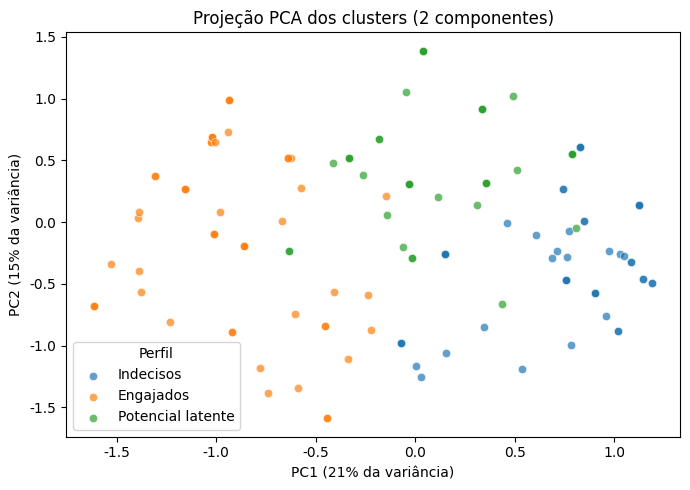

In [10]:
# Redução para 2 dimensões com PCA para visualização

pca = PCA(n_components=2, random_state=2026)
componentes = pca.fit_transform(X)

plt.figure(figsize=(7, 5))
for cluster_id, nome in rotulos.items():
    mask = df_cluster["cluster"] == cluster_id
    plt.scatter(
        componentes[mask, 0],
        componentes[mask, 1],
        label=nome,
        alpha=0.7,
        edgecolors="w",
        linewidth=0.5,
    )

plt.title("Projeção PCA dos clusters (2 componentes)")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.0%} da variância)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.0%} da variância)")
plt.legend(title="Perfil")
plt.tight_layout()
plt.savefig(DOCS_DIR / "02_pca_clusters.png", dpi=150, bbox_inches="tight")
plt.show()

In [11]:
# Análise detalhada do cluster "Potencial latente":
# grupo que demonstra interesse em aprender mas nunca tentou reutilizar.
# Principal alvo de intervenção para programas de educação ambiental.

df_potencial = df_cluster[df_cluster["perfil"] == "Potencial latente"]

print("Interesse em aprender:")
print(df_potencial["interesse_aprender"].value_counts(normalize=True))
print()
print("Tentativa de reutilização:")
print(df_potencial["tentativa_reutilizacao"].value_counts(normalize=True))

Interesse em aprender:
interesse_aprender
Sim    0.755556
Não    0.244444
Name: proportion, dtype: float64

Tentativa de reutilização:
tentativa_reutilizacao
Não    1.0
Name: proportion, dtype: float64


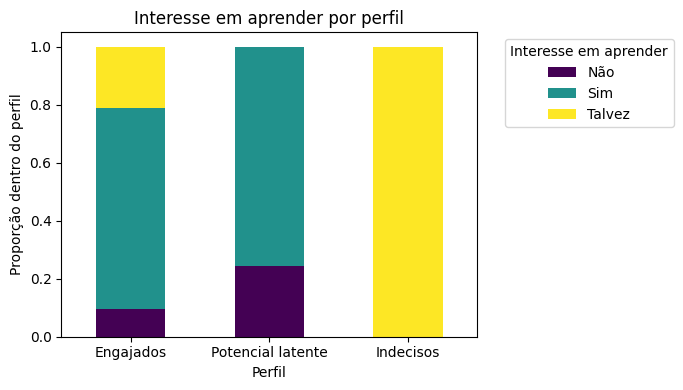

In [12]:
tab = pd.crosstab(df_cluster["perfil"], df_cluster["interesse_aprender"], normalize="index")
tab = tab.reindex(["Engajados", "Potencial latente", "Indecisos"])

tab.plot(kind="bar", stacked=True, figsize=(7, 4), colormap="viridis")
plt.title("Interesse em aprender por perfil")
plt.xlabel("Perfil")
plt.ylabel("Proporção dentro do perfil")
plt.legend(title="Interesse em aprender", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Limitações do protótipo

Este notebook é um MVP exploratório e possui limitações conhecidas: a amostra é preliminar (n=161, coleta em andamento), apenas 6 das 19 variáveis disponíveis foram utilizadas no modelo, e o número de clusters (k=3) foi uma escolha exploratória, sem validação formal por métricas como silhouette score ou método do cotovelo. Os resultados servem como ponto de partida para a definição de uma metodologia mais robusta nas próximas fases do projeto.